In [1]:
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import train_test_split
from collections import Counter

print("All imports successful!")
print(f"PyTorch version: {torch.__version__}")

All imports successful!
PyTorch version: 2.12.0


In [2]:
dataset_path = "data/raw/PlantVillage"

# Get all class names (skip hidden files and nested folder)
classes = sorted([
    c for c in os.listdir(dataset_path)
    if not c.startswith('.') and c != 'PlantVillage'
])

# Create a mapping from class name to a number
class_to_idx = {class_name: idx for idx, class_name in enumerate(classes)}

# Collect all image paths and their labels
all_image_paths = []
all_labels = []

for class_name in classes:
    class_path = os.path.join(dataset_path, class_name)
    for img_name in os.listdir(class_path):
        if img_name.endswith(('.jpg', '.JPG', '.png', '.PNG')):
            all_image_paths.append(os.path.join(class_path, img_name))
            all_labels.append(class_to_idx[class_name])

print(f"Total images found: {len(all_image_paths)}")
print(f"Total classes: {len(classes)}")
print(f"\nClass to index mapping:")
for class_name, idx in class_to_idx.items():
    print(f"  {idx:2d} → {class_name}")

Total images found: 20637
Total classes: 15

Class to index mapping:
   0 → Pepper__bell___Bacterial_spot
   1 → Pepper__bell___healthy
   2 → Potato___Early_blight
   3 → Potato___Late_blight
   4 → Potato___healthy
   5 → Tomato_Bacterial_spot
   6 → Tomato_Early_blight
   7 → Tomato_Late_blight
   8 → Tomato_Leaf_Mold
   9 → Tomato_Septoria_leaf_spot
  10 → Tomato_Spider_mites_Two_spotted_spider_mite
  11 → Tomato__Target_Spot
  12 → Tomato__Tomato_YellowLeaf__Curl_Virus
  13 → Tomato__Tomato_mosaic_virus
  14 → Tomato_healthy


In [3]:
# First split: 85% train+val, 15% test
train_val_paths, test_paths, train_val_labels, test_labels = train_test_split(
    all_image_paths, all_labels,
    test_size=0.15,
    random_state=42,
    stratify=all_labels  # ensures each split has same class proportions
)

# Second split: 70% train, 15% val (from the 85%)
train_paths, val_paths, train_labels, val_labels = train_test_split(
    train_val_paths, train_val_labels,
    test_size=0.176,  # 0.176 of 85% ≈ 15% of total
    random_state=42,
    stratify=train_val_labels
)

print(f"Training images:   {len(train_paths)}")
print(f"Validation images: {len(val_paths)}")
print(f"Test images:       {len(test_paths)}")
print(f"Total:             {len(train_paths) + len(val_paths) + len(test_paths)}")

Training images:   14453
Validation images: 3088
Test images:       3096
Total:             20637


In [4]:
class PlantDiseaseDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform

    def __len__(self):
        # tells PyTorch how many images are in this dataset
        return len(self.image_paths)

    def __getitem__(self, idx):
        # loads one image by index
        img = Image.open(self.image_paths[idx]).convert('RGB')
        label = self.labels[idx]

        if self.transform:
            img = self.transform(img)

        return img, label

print("Dataset class defined successfully!")

# Quick test - load one image manually
test_dataset = PlantDiseaseDataset(train_paths, train_labels, transform=None)
img, label = test_dataset[0]
print(f"\nSample image size: {img.size}")
print(f"Sample label: {label} → {classes[label]}")
print(f"Total items in dataset: {len(test_dataset)}")

Dataset class defined successfully!

Sample image size: (256, 256)
Sample label: 9 → Tomato_Septoria_leaf_spot
Total items in dataset: 14453


In [5]:
# Training transforms - includes augmentation to prevent overfitting
train_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomVerticalFlip(p=0.2),
    transforms.RandomRotation(degrees=15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Validation and test transforms - no augmentation, just resize and normalize
val_transform = transforms.Compose([
    transforms.Resize((224, 224)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

print("Transforms defined!")
print("\nTraining transform steps:")
for i, t in enumerate(train_transform.transforms):
    print(f"  {i+1}. {t.__class__.__name__}")

Transforms defined!

Training transform steps:
  1. Resize
  2. RandomHorizontalFlip
  3. RandomVerticalFlip
  4. RandomRotation
  5. ColorJitter
  6. ToTensor
  7. Normalize


In [6]:
# Create datasets with transforms
train_dataset = PlantDiseaseDataset(train_paths, train_labels, transform=train_transform)
val_dataset = PlantDiseaseDataset(val_paths, val_labels, transform=val_transform)
test_dataset = PlantDiseaseDataset(test_paths, test_labels, transform=val_transform)

# Create dataloaders
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True, num_workers=0)
val_loader = DataLoader(val_dataset, batch_size=32, shuffle=False, num_workers=0)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=False, num_workers=0)

print("Datasets created:")
print(f"  Train dataset: {len(train_dataset)} images")
print(f"  Val dataset:   {len(val_dataset)} images")
print(f"  Test dataset:  {len(test_dataset)} images")

print("\nDataLoaders created:")
print(f"  Train batches: {len(train_loader)}")
print(f"  Val batches:   {len(val_loader)}")
print(f"  Test batches:  {len(test_loader)}")

# Load one batch and check the shape
images, labels = next(iter(train_loader))
print(f"\nOne batch shape:")
print(f"  Images: {images.shape}  → (batch_size, channels, height, width)")
print(f"  Labels: {labels.shape}  → (batch_size,)")

Datasets created:
  Train dataset: 14453 images
  Val dataset:   3088 images
  Test dataset:  3096 images

DataLoaders created:
  Train batches: 452
  Val batches:   97
  Test batches:  97

One batch shape:
  Images: torch.Size([32, 3, 224, 224])  → (batch_size, channels, height, width)
  Labels: torch.Size([32])  → (batch_size,)


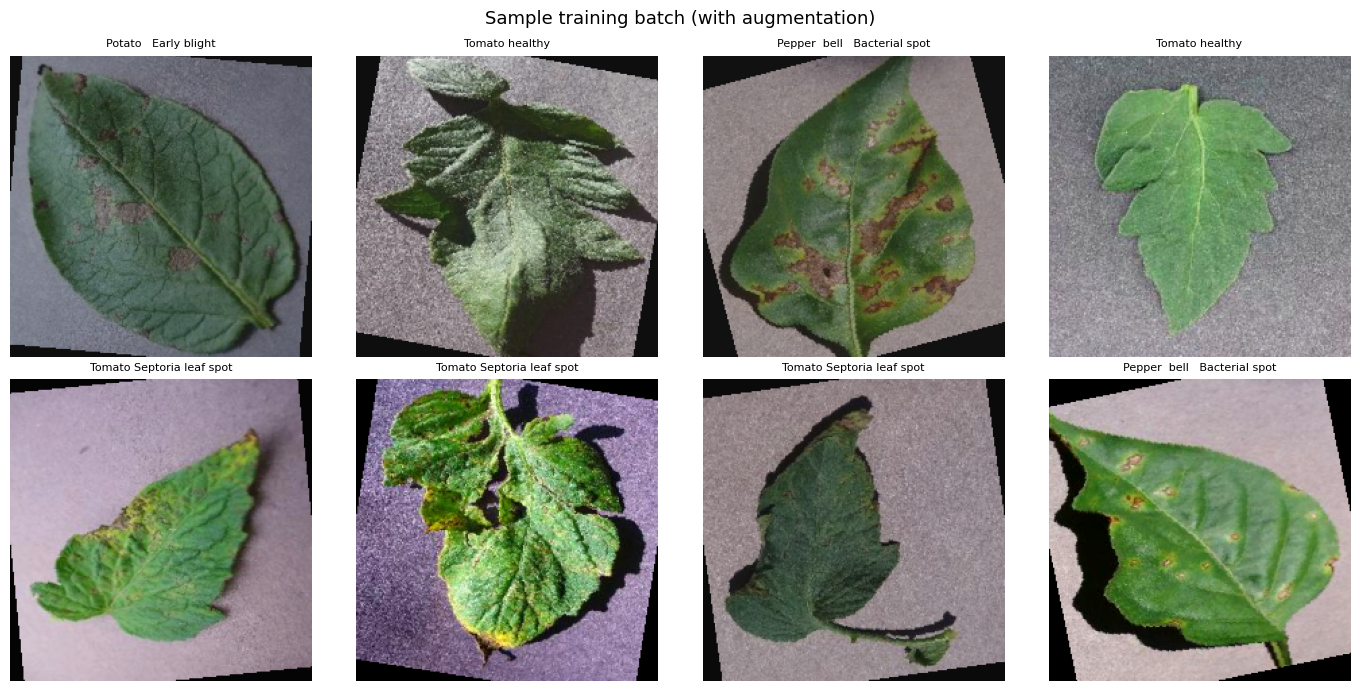

Saved to outputs/sample_batch.png


In [7]:
# Undo the normalization so images look normal when displayed
def denormalize(tensor):
    mean = torch.tensor([0.485, 0.456, 0.406]).view(3, 1, 1)
    std = torch.tensor([0.229, 0.224, 0.225]).view(3, 1, 1)
    return torch.clamp(tensor * std + mean, 0, 1)

# Grab one batch
images, labels = next(iter(train_loader))

# Show first 8 images
fig, axes = plt.subplots(2, 4, figsize=(14, 7))
axes = axes.flatten()

for i in range(8):
    img = denormalize(images[i])
    img = img.permute(1, 2, 0).numpy()  # convert from (C,H,W) to (H,W,C)
    axes[i].imshow(img)
    axes[i].set_title(classes[labels[i].item()].replace("_", " "), fontsize=8)
    axes[i].axis('off')

plt.suptitle("Sample training batch (with augmentation)", fontsize=13)
plt.tight_layout()
plt.savefig('outputs/sample_batch.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved to outputs/sample_batch.png")

In [8]:
import pickle

# Save all the data splits and class info so we don't redo this work
data_to_save = {
    'train_paths': train_paths,
    'val_paths': val_paths,
    'test_paths': test_paths,
    'train_labels': train_labels,
    'val_labels': val_labels,
    'test_labels': test_labels,
    'classes': classes,
    'class_to_idx': class_to_idx
}

with open('data/processed/data_splits.pkl', 'wb') as f:
    pickle.dump(data_to_save, f)

print("Data splits saved to data/processed/data_splits.pkl")
print("\nSummary of what's saved:")
print(f"  Classes:          {len(classes)}")
print(f"  Train images:     {len(train_paths)}")
print(f"  Val images:       {len(val_paths)}")
print(f"  Test images:      {len(test_paths)}")
print("\nReady for Day 4!")

Data splits saved to data/processed/data_splits.pkl

Summary of what's saved:
  Classes:          15
  Train images:     14453
  Val images:       3088
  Test images:      3096

Ready for Day 4!
